# Sampling


## Imports


In [12]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.sampler_utils import (
    atoms_to_structures,
    load_reduced,
    pc_coverage_bins_auto,
    sample,
    sample_to_coverage,
    sample_to_coverage_seeded_batches,
)
from src.plots_exports_utils import plot_sampling_pca, export_selected_structures
from src.workflow_config import ensure_directory


## Inputs


In [13]:
# X can be the original standardized SOAP or a reduced matrix (e.g., PCA)
embedded_file = True
if embedded_file:
    embedding_dir = Path("embedding")
    npy_files = sorted(embedding_dir.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError("No .npy file found in embedding/")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using embedding: {npy_file}")
    X = load_reduced(npy_file)
    print("Loaded embedding with shape:", X.shape)
else:
    npy_files = sorted(Path(".").glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError("No .npy file found in current directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using standardized SOAP matrix: {npy_file}")
    X = load_reduced(npy_file)

desc_dir = Path("desc")
provenance_files = list(desc_dir.glob("*.parquet")) + list(desc_dir.glob("*.csv"))
if not provenance_files:
    raise FileNotFoundError("No provenance table found in desc/")
provenance_files = sorted(provenance_files)
provenance_file = next((p for p in provenance_files if p.suffix == ".parquet"), provenance_files[0])
print(f"Using provenance file: {provenance_file}")
if provenance_file.suffix == ".parquet":
    meta = pd.read_parquet(provenance_file)
else:
    meta = pd.read_csv(provenance_file)

json_files = [p for p in desc_dir.glob("*.json") if "filemap" in p.name]
if not json_files:
    raise FileNotFoundError("No filemap JSON found in desc/")
if len(json_files) > 1:
    raise RuntimeError(f"Multiple JSON matches found: {json_files}")
json_file = json_files[0]
print(f"Using filemap: {json_file}")
with open(json_file) as f:
    filemap = json.load(f)

path_to_results = ensure_directory("selected")

print("X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))

# 1) whiten (float64 for stability)
X = np.asarray(X, dtype=np.float64, order="C")
mu = X.mean(axis=0, keepdims=True)
sd = X.std(axis=0, keepdims=True) + 1e-12
X = (X - mu) / sd

print("Whitened X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))


Using embedding: embedding/pca_embedding.npy
Loaded embedding with shape: (361746, 5)
Using provenance file: desc/SOAP_C-O-S_20260407-170426_provenance.parquet
Using filemap: desc/SOAP_C-O-S_20260407-170426_filemap.json
X dtype/shape: float64 (361746, 5)
has_nan: False has_inf: False abs max: 26.901365202147694
Whitened X dtype/shape: float64 (361746, 5)
has_nan: False has_inf: False abs max: 12.351091647857261


## Sampling algorithms


## FPS sampling


Using seeded batches auto-sampling strategy
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [00:00<00:00, 259.34it/s]


[fps-seeded] k=100 mean_cov=0.593
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [00:00<00:00, 259.21it/s]


[fps-seeded] +100 → k=200 mean_cov=0.736
Using Farthest-Point Sampling (FPS) ...


...

[fps-seeded] +100 → k=1,300 mean_cov=0.944
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [00:00<00:00, 256.74it/s]


[fps-seeded] +100 → k=1,400 mean_cov=0.947
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [00:00<00:00, 260.36it/s]


[fps-seeded] +100 → k=1,500 mean_cov=0.951
[fps] seeded auto-stop at k=1,500 with mean_cov=0.951
Per-PC bins used: [50, 54, 153, 144, 103]
Per-PC coverage: [1.0, 1.0, 0.9577464788732394, 0.9930555555555556, 0.8058252427184466]
Selected 1123 unique structures.


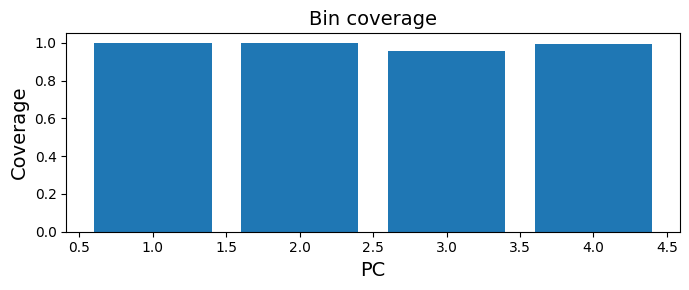

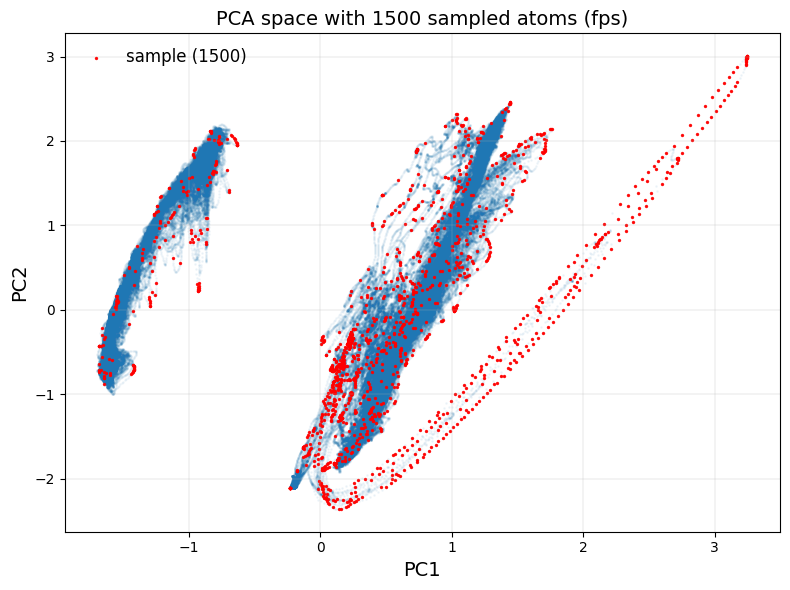

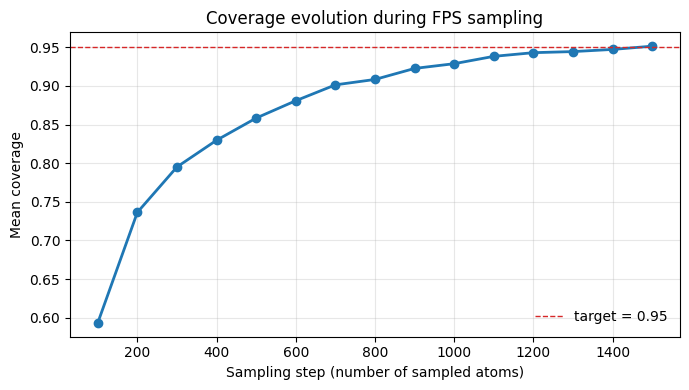

Assembling: 100%|██████████| 1123/1123 [00:00<00:00, 76074.09it/s]


{'traj': '/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/selected/FPS_selected.traj', 'xyz': '/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/selected/FPS_selected.xyz'}


In [14]:
# --- config ---
method = "fps"                  # "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
auto_sampling = True            # True -> stop at target coverage, False -> fixed k
auto_strategy = "seeded"        # "resample" or "seeded"
fixed_k = 50_000                # used if auto_sampling == False
seed = 0
progress = True

# auto params
target_mean_cov = 0.95
coverage_mode = "width"
target_width = 0.10
min_bins = 20
max_bins = 10_000

# resample-mode params
k_start = 100
k_max = 200_000
growth = 1.25
check_every = None

# seeded-batches-mode params
batch = 100
k_max_seeded = 200_000

# --- sampling ---
if auto_sampling:
    if auto_strategy == "seeded":
        print("Using seeded batches auto-sampling strategy")
        idx_atoms, info = sample_to_coverage_seeded_batches(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, batch=batch, k_max=k_max_seeded, seed=seed, progress=progress,
            coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        coverage_history = info["history"]
        print(f"[{method}] seeded auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
    else:
        print("Using resample auto-sampling strategy")
        idx_atoms, info = sample_to_coverage(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, k_max=k_max, growth=growth, check_every=check_every,
            seed=seed, coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins, progress=progress
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        coverage_history = info["history"]
        print(f"[{method}] resample auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
else:
    print("Using fixed-k sampling strategy")
    idx_atoms = sample(X, method=method, k=fixed_k, seed=seed, progress=progress)
    per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
        X, idx_atoms, mode=coverage_mode, target_width=target_width,
        min_bins=min_bins, max_bins=max_bins
    )
    print(f"[{method}] fixed k={fixed_k:,} mean_cov={mean_cov:.3f}")
    coverage_history = [{"k": int(len(idx_atoms)), "mean_cov": float(mean_cov)}]

print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc[:8])

# --- lift to structures ---
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")

# --- save ---
np.save(path_to_results / f"sampled_atom_indices_{method}.npy", idx_atoms)
chosen_structs.to_csv(path_to_results / f"sampled_structures_{method}.csv", index=False)

# --- plot ---
plot_sampling_pca(X, idx_atoms, method=method, per_pc=per_pc, npy_file=npy_file, outdir=path_to_results)

# --- coverage evolution plot ---
steps = [point["k"] for point in coverage_history]
mean_coverages = [point["mean_cov"] for point in coverage_history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, mean_coverages, marker="o", linewidth=2)
ax.set_xlabel("Sampling step (number of sampled atoms)")
ax.set_ylabel("Mean coverage")
ax.set_title(f"Coverage evolution during {method.upper()} sampling")
ax.grid(True, alpha=0.3)
if auto_sampling:
    ax.axhline(target_mean_cov, color="tab:red", linestyle="--", linewidth=1, label=f"target = {target_mean_cov:.2f}")
    ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(path_to_results / f"{method}_coverage_evolution.png", dpi=300)
plt.show()

# --- optional export ---
save_files = True
if save_files:
    paths = export_selected_structures(
        chosen_structs, method_name=method.upper(), outdir=path_to_results,
        extra_formats=("xyz",), load_mode="auto"
    )
    print(paths)
